In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
raw = pd.read_csv("06-05-26_WLT_134-136.csv", encoding="utf-16", 
                  header=None, skiprows=6)
raw.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,0,-0.073301,0,-0.079038,0,-0.079603,0,-0.059797,0,-0.067254,0,-0.064565,0,-0.084398,0,-0.075216,0,-0.077394
1,10,-0.073288,10,-0.078977,10,-0.079530,10,-0.059386,10,-0.067044,10,-0.064372,10,-0.084426,10,-0.075239,10,-0.077395
2,20,-0.073274,20,-0.078917,20,-0.079462,20,-0.059020,20,-0.066839,20,-0.064209,20,-0.084442,20,-0.075254,20,-0.077379
3,30,-0.073262,30,-0.078858,30,-0.079392,30,-0.058695,30,-0.066644,30,-0.064085,30,-0.084434,30,-0.075254,30,-0.077356
4,40,-0.073251,40,-0.078801,40,-0.079325,40,-0.058400,40,-0.066455,40,-0.063982,40,-0.084410,40,-0.075239,40,-0.077324


In [17]:
raw.shape

(121, 18)

In [18]:
# Dropping duplicate time columns
# Original: t1,E1, t2,E2, ... t9,E9 → we keep t1 + all 9 E columns
voltage_cols = list(range(1, 18, 2)) # indices 1,3,5,7,9,11,13,15,17 → E columns
time_col = [0] # index 0 → single time column

df = raw[time_col + voltage_cols].copy()
df.head()

,0,1,3,5,7,9,11,13,15,17
0,0,-0.073301,-0.079038,-0.079603,-0.059797,-0.067254,-0.064565,-0.084398,-0.075216,-0.077394
1,10,-0.073288,-0.078977,-0.079530,-0.059386,-0.067044,-0.064372,-0.084426,-0.075239,-0.077395
2,20,-0.073274,-0.078917,-0.079462,-0.059020,-0.066839,-0.064209,-0.084442,-0.075254,-0.077379
3,30,-0.073262,-0.078858,-0.079392,-0.058695,-0.066644,-0.064085,-0.084434,-0.075254,-0.077356
4,40,-0.073251,-0.078801,-0.079325,-0.058400,-0.066455,-0.063982,-0.084410,-0.075239,-0.077324


In [19]:
# Assign clean column names
df.columns = ["t_s","E_CaCl2_1_Ch1", "E_CaCl2_1_Ch2", "E_CaCl2_1_Ch3",
              "E_NaCl_Ch1",    "E_NaCl_Ch2",    "E_NaCl_Ch3",
              "E_CaCl2_2_Ch1", "E_CaCl2_2_Ch2", "E_CaCl2_2_Ch3",]
df.head()

,t_s,E_CaCl2_1_Ch1,E_CaCl2_1_Ch2,E_CaCl2_1_Ch3,E_NaCl_Ch1,E_NaCl_Ch2,E_NaCl_Ch3,E_CaCl2_2_Ch1,E_CaCl2_2_Ch2,E_CaCl2_2_Ch3
0,0,-0.073301,-0.079038,-0.079603,-0.059797,-0.067254,-0.064565,-0.084398,-0.075216,-0.077394
1,10,-0.073288,-0.078977,-0.079530,-0.059386,-0.067044,-0.064372,-0.084426,-0.075239,-0.077395
2,20,-0.073274,-0.078917,-0.079462,-0.059020,-0.066839,-0.064209,-0.084442,-0.075254,-0.077379
3,30,-0.073262,-0.078858,-0.079392,-0.058695,-0.066644,-0.064085,-0.084434,-0.075254,-0.077356
4,40,-0.073251,-0.078801,-0.079325,-0.058400,-0.066455,-0.063982,-0.084410,-0.075239,-0.077324


In [20]:
df.shape

(121, 10)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   t_s            121 non-null    int64  
 1   E_CaCl2_1_Ch1  121 non-null    float64
 2   E_CaCl2_1_Ch2  121 non-null    float64
 3   E_CaCl2_1_Ch3  121 non-null    float64
 4   E_NaCl_Ch1     121 non-null    float64
 5   E_NaCl_Ch2     121 non-null    float64
 6   E_NaCl_Ch3     121 non-null    float64
 7   E_CaCl2_2_Ch1  121 non-null    float64
 8   E_CaCl2_2_Ch2  121 non-null    float64
 9   E_CaCl2_2_Ch3  121 non-null    float64
dtypes: float64(9), int64(1)
memory usage: 9.6 KB


In [22]:
# statistics of our data
df.describe()

,t_s,E_CaCl2_1_Ch1,E_CaCl2_1_Ch2,E_CaCl2_1_Ch3,E_NaCl_Ch1,E_NaCl_Ch2,E_NaCl_Ch3,E_CaCl2_2_Ch1,E_CaCl2_2_Ch2,E_CaCl2_2_Ch3
count,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000
mean,600.000000,-0.073022,-0.077025,-0.077702,-0.054797,-0.062946,-0.062848,-0.082013,-0.074621,-0.075952
std,350.737319,0.000099,0.000916,0.000719,0.001358,0.001507,0.000557,0.001296,0.000217,0.000691
min,0.000000,-0.073301,-0.079038,-0.079603,-0.059797,-0.067254,-0.064565,-0.084442,-0.075254,-0.077395
25%,300.000000,-0.073071,-0.077690,-0.078056,-0.055134,-0.063758,-0.063263,-0.083012,-0.074637,-0.076449
50%,600.000000,-0.072992,-0.076881,-0.077508,-0.054256,-0.062553,-0.062776,-0.081840,-0.074520,-0.075739
75%,900.000000,-0.072944,-0.076245,-0.077144,-0.053853,-0.061731,-0.062373,-0.080903,-0.074489,-0.075410
max,1200.000000,-0.072920,-0.075729,-0.076876,-0.053733,-0.061188,-0.062076,-0.080090,-0.074473,-0.075059


In [23]:
# checking if there are null values
df.isnull().sum()

t_s              0
E_CaCl2_1_Ch1    0
E_CaCl2_1_Ch2    0
E_CaCl2_1_Ch3    0
E_NaCl_Ch1       0
E_NaCl_Ch2       0
E_NaCl_Ch3       0
E_CaCl2_2_Ch1    0
E_CaCl2_2_Ch2    0
E_CaCl2_2_Ch3    0
dtype: int64

In [24]:
# checking if there are invalid values
invalid_mask = df.apply(lambda col: pd.to_numeric(col, errors='coerce').isna() & col.notna())
invalid_mask.sum()

t_s              0
E_CaCl2_1_Ch1    0
E_CaCl2_1_Ch2    0
E_CaCl2_1_Ch3    0
E_NaCl_Ch1       0
E_NaCl_Ch2       0
E_NaCl_Ch3       0
E_CaCl2_2_Ch1    0
E_CaCl2_2_Ch2    0
E_CaCl2_2_Ch3    0
dtype: int64

### Plot OCP vs time for all 3 channels

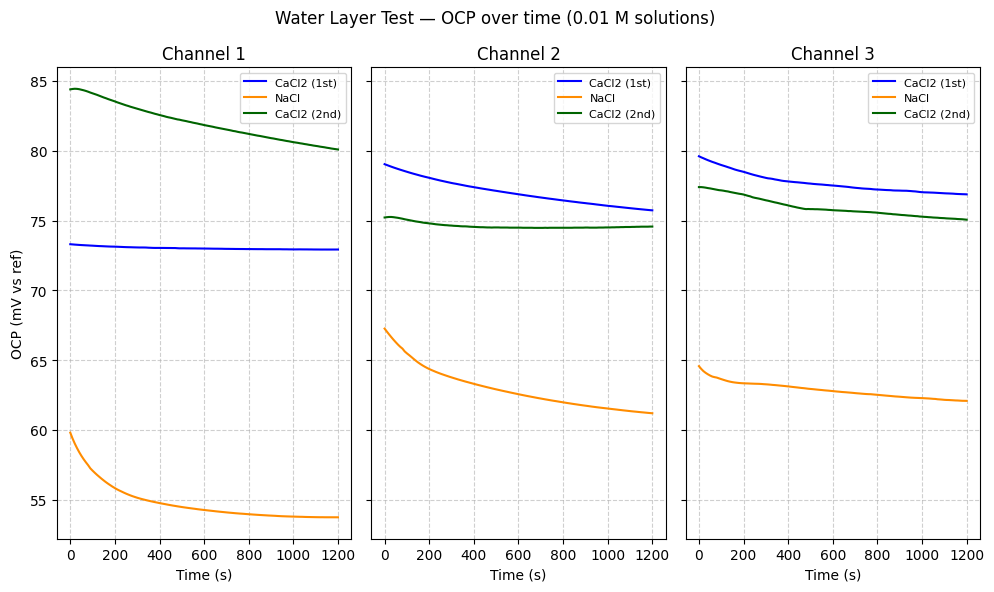

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(10, 6), sharey=True)

colors = {"CaCl2_1": "blue", "NaCl": "darkorange", "CaCl2_2": "darkgreen"}
labels = {"CaCl2_1": "CaCl2 (1st)", "NaCl": "NaCl", "CaCl2_2": "CaCl2 (2nd)"}
runs   = ["CaCl2_1", "NaCl", "CaCl2_2"]
channels = [1, 2, 3]

for i, ch in enumerate(channels):
    ax = axes[i]
    for run in runs:
        E = df[f"E_{run}_Ch{ch}"]
        ax.plot(df["t_s"], -E * 1000, color=colors[run], label=labels[run])
    ax.set_title(f"Channel {ch}")
    ax.set_xlabel("Time (s)")
    if i == 0:
        ax.set_ylabel("OCP (mV vs ref)")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Water Layer Test — OCP over time (0.01 M solutions)")
plt.tight_layout()
plt.savefig("WLT_OCP_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
# OCP Shifts at every time step
channels = [1, 2, 3]

# 1. CaCl2_1 → NaCl shift
for ch in channels:
    df[f"dE_CaCl2_1_to_NaCl_Ch{ch}"] = (df[f"E_NaCl_Ch{ch}"] - df[f"E_CaCl2_1_Ch{ch}"])

# 2. NaCl → CaCl2_2 shift
for ch in channels:
    df[f"dE_NaCl_to_CaCl2_2_Ch{ch}"] = (df[f"E_CaCl2_2_Ch{ch}"] - df[f"E_NaCl_Ch{ch}"])

# 3. CaCl2_1 → CaCl2_2 (reversibility)
for ch in channels:
    df[f"dE_reversibility_Ch{ch}"] = (df[f"E_CaCl2_2_Ch{ch}"] - df[f"E_CaCl2_1_Ch{ch}"])

df

,t_s,E_CaCl2_1_Ch1,E_CaCl2_1_Ch2,E_CaCl2_1_Ch3,E_NaCl_Ch1,E_NaCl_Ch2,E_NaCl_Ch3,E_CaCl2_2_Ch1,E_CaCl2_2_Ch2,E_CaCl2_2_Ch3,dE_CaCl2_1_to_NaCl_Ch1,dE_CaCl2_1_to_NaCl_Ch2,dE_CaCl2_1_to_NaCl_Ch3,dE_NaCl_to_CaCl2_2_Ch1,dE_NaCl_to_CaCl2_2_Ch2,dE_NaCl_to_CaCl2_2_Ch3,dE_reversibility_Ch1,dE_reversibility_Ch2,dE_reversibility_Ch3
0,0,-0.073301,-0.079038,-0.079603,-0.059797,-0.067254,-0.064565,-0.084398,-0.075216,-0.077394,0.013504,0.011784,0.015038,-0.024601,-0.007963,-0.012830,-0.011097,0.003822,0.002209
1,10,-0.073288,-0.078977,-0.079530,-0.059386,-0.067044,-0.064372,-0.084426,-0.075239,-0.077395,0.013902,0.011933,0.015158,-0.025040,-0.008194,-0.013023,-0.011138,0.003739,0.002135
2,20,-0.073274,-0.078917,-0.079462,-0.059020,-0.066839,-0.064209,-0.084442,-0.075254,-0.077379,0.014254,0.012078,0.015253,-0.025422,-0.008415,-0.013170,-0.011168,0.003663,0.002083
3,30,-0.073262,-0.078858,-0.079392,-0.058695,-0.066644,-0.064085,-0.084434,-0.075254,-0.077356,0.014567,0.012215,0.015307,-0.025739,-0.008611,-0.013271,-0.011172,0.003604,0.002036
4,40,-0.073251,-0.078801,-0.079325,-0.058400,-0.066455,-0.063982,-0.084410,-0.075239,-0.077324,0.014851,0.012346,0.015343,-0.026011,-0.008783,-0.013343,-0.011160,0.003563,0.002000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,1160,-0.072920,-0.075789,-0.076901,-0.053734,-0.061247,-0.062102,-0.080192,-0.074559,-0.075106,0.019186,0.014541,0.014798,-0.026458,-0.013311,-0.013004,-0.007272,0.001230,0.001795
117,1170,-0.072920,-0.075773,-0.076894,-0.053734,-0.061232,-0.062092,-0.080160,-0.074559,-0.075098,0.019186,0.014541,0.014802,-0.026426,-0.013327,-0.013006,-0.007240,0.001215,0.001796
118,1180,-0.072921,-0.075758,-0.076887,-0.053733,-0.061216,-0.062082,-0.080137,-0.074559,-0.075090,0.019188,0.014541,0.014806,-0.026404,-0.013343,-0.013008,-0.007216,0.001199,0.001797
119,1190,-0.072921,-0.075743,-0.076883,-0.053733,-0.061202,-0.062080,-0.080114,-0.074567,-0.075074,0.019188,0.014541,0.014803,-0.026380,-0.013364,-0.012995,-0.007193,0.001176,0.001808


In [27]:
# Summary at key time points
key_times = [0, 100, 300, 600, 900, 1200]
print("=" * 70)
print(f"{'Time(s)':<8} {'Channel':<9} {'CaCl2→NaCl (mV)':<18} {'NaCl→CaCl2 (mV)':<18} {'Reversibility (mV)'}")
print("=" * 70)

for t in key_times:
    row = df[df["t_s"] == t]
    for ch in channels:
        print(f"{t:<10} {ch:<10}"
              f"{row[f'dE_CaCl2_1_to_NaCl_Ch{ch}'].values[0]:<20.4f}"
              f"{row[f'dE_NaCl_to_CaCl2_2_Ch{ch}'].values[0]:<20.4f}"
              f"{row[f'dE_reversibility_Ch{ch}'].values[0]:.4f}")
    print("-" * 70)

Time(s)  Channel   CaCl2→NaCl (mV)    NaCl→CaCl2 (mV)    Reversibility (mV)
0          1         0.0135              -0.0246             -0.0111
0          2         0.0118              -0.0080             0.0038
0          3         0.0150              -0.0128             0.0022
----------------------------------------------------------------------
100        1         0.0161              -0.0270             -0.0109
100        2         0.0130              -0.0096             0.0034
100        3         0.0153              -0.0135             0.0018
----------------------------------------------------------------------
300        1         0.0179              -0.0279             -0.0099
300        2         0.0139              -0.0109             0.0031
300        3         0.0148              -0.0132             0.0016
----------------------------------------------------------------------
600        1         0.0187              -0.0276             -0.0088
600        2         0.0143

In [28]:
rev_Ch1 = df["E_CaCl2_2_Ch1"] - df["E_CaCl2_1_Ch1"]
print(f"Reversibility error Ch1: {rev_Ch1.mean()*1000:.3f} mV")
rev_Ch2 = df["E_CaCl2_2_Ch2"] - df["E_CaCl2_1_Ch2"]
print(f"Reversibility error Ch2: {rev_Ch2.mean()*1000:.3f} mV")
rev_Ch3 = df["E_CaCl2_2_Ch3"] - df["E_CaCl2_1_Ch3"]
print(f"Reversibility error Ch3: {rev_Ch3.mean()*1000:.3f} mV")

Reversibility error Ch1: -8.992 mV
Reversibility error Ch2: 2.404 mV
Reversibility error Ch3: 1.750 mV


### Plot OCP shifts over time

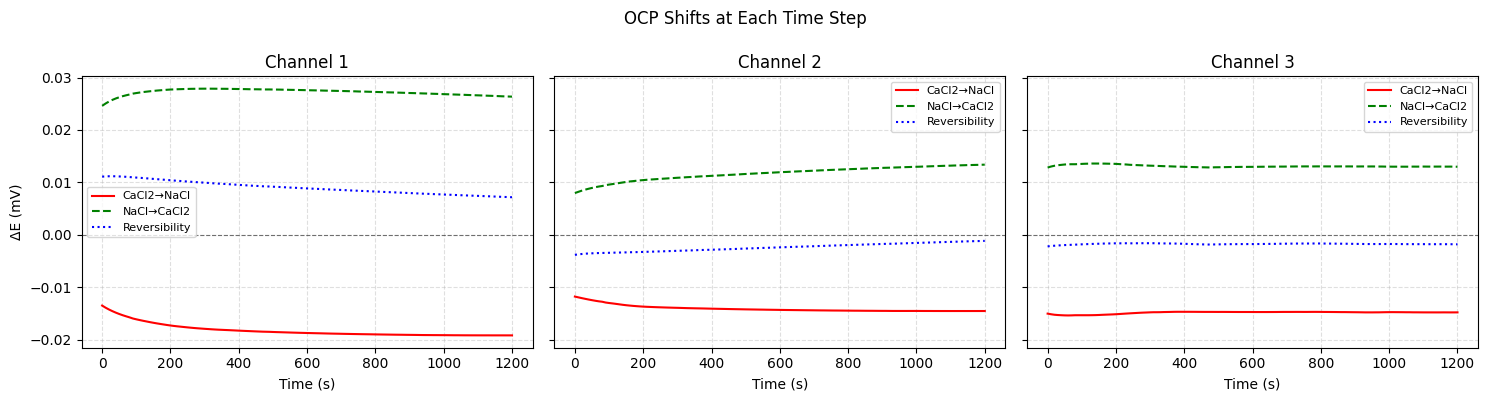

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

shift_styles = {
    "CaCl2→NaCl":    ("dE_CaCl2_1_to_NaCl", "red", "-"),
    "NaCl→CaCl2":    ("dE_NaCl_to_CaCl2_2", "green", "--"),
    "Reversibility": ("dE_reversibility", "blue", ":"),
}

for i, ch in enumerate(channels):
    ax = axes[i]
    for shift_label, (col_prefix, color, ls) in shift_styles.items():
        ax.plot(df["t_s"], -df[f"{col_prefix}_Ch{ch}"],
                color=color, linestyle=ls, linewidth=1.5, label=shift_label)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_title(f"Channel {ch}")
    ax.set_xlabel("Time (s)")
    if i == 0:
        ax.set_ylabel("ΔE (mV)")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("OCP Shifts at Each Time Step", y=0.99)
plt.tight_layout()
plt.savefig("WLT_OCP_shifts.png", dpi=150, bbox_inches="tight")
plt.show()

## Stitch all 3 runs on one continuous timeline.
#### Each run is 1200s = 20 min. Total = 3600s = 60 min
#### We offset run-2(NaCl) by 1200s and run-3(CaCl2_2) by 2400s


In [30]:
df_cacl2_1 = df[["t_s", "E_CaCl2_1_Ch1", "E_CaCl2_1_Ch2", "E_CaCl2_1_Ch3"]].copy()
df_cacl2_1.columns = ["t_s", "Ch1", "Ch2", "Ch3"]
df_cacl2_1["t_s"] = df_cacl2_1["t_s"]                  # 0 → 1200s

df_nacl = df[["t_s", "E_NaCl_Ch1", "E_NaCl_Ch2", "E_NaCl_Ch3"]].copy()
df_nacl.columns = ["t_s", "Ch1", "Ch2", "Ch3"]
df_nacl["t_s"] = df_nacl["t_s"] + 1200                  # 1200 → 2400s

df_cacl2_2 = df[["t_s", "E_CaCl2_2_Ch1", "E_CaCl2_2_Ch2", "E_CaCl2_2_Ch3"]].copy()
df_cacl2_2.columns = ["t_s", "Ch1", "Ch2", "Ch3"]
df_cacl2_2["t_s"] = df_cacl2_2["t_s"] + 2400            # 2400 → 3600s

stitched = pd.concat([df_cacl2_1, df_nacl, df_cacl2_2], ignore_index=True)

stitched["t_s"] = stitched["t_s"] / 60
stitched.rename(columns={"t_s": "t_mins"}, inplace=True)

In [31]:
stitched.shape

(363, 4)

In [32]:
stitched['Ch1'] = -stitched['Ch1']
stitched['Ch2'] = -stitched['Ch2']
stitched['Ch3'] = -stitched['Ch3']

In [33]:
stitched.head() # 0-120 => CaCl2_1, 121-241 => Nacl & 242-362 => CaCl2_2

,t_mins,Ch1,Ch2,Ch3
0,0.000000,0.073301,0.079038,0.079603
1,0.166667,0.073288,0.078977,0.079530
2,0.333333,0.073274,0.078917,0.079462
3,0.500000,0.073262,0.078858,0.079392
4,0.666667,0.073251,0.078801,0.079325


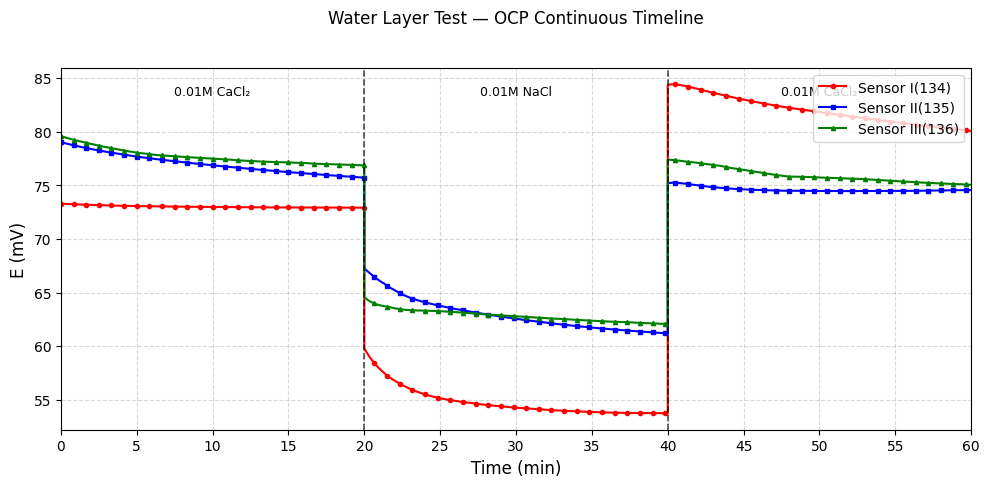

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))
channels = ['Ch1', 'Ch2', 'Ch3']
colors  = ["red", "blue", "green"]
markers = ["o", "s", "^"]
labels  = ["Sensor I(134)", "Sensor II(135)", "Sensor III(136)"]

for ch, color, marker, label in zip(channels, colors, markers, labels):
    ax.plot(stitched["t_mins"], stitched[ch] * 1000, # E in mV
            color=color, linewidth=1.5,
            marker=marker, markevery=5,
            markersize=3, label=label)

# Vertical lines at solution change points
ax.axvline(x=20, color="black", linestyle="--", linewidth=1.2, alpha=0.7)
ax.axvline(x=40, color="black", linestyle="--", linewidth=1.2, alpha=0.7)

# Solution labels at the top
ax.text(10, ax.get_ylim()[1] * 0.97, "0.01M CaCl₂", ha="center", fontsize=9, color="black")
ax.text(30, ax.get_ylim()[1] * 0.97, "0.01M NaCl",  ha="center", fontsize=9, color="black")
ax.text(50, ax.get_ylim()[1] * 0.97, "0.01M CaCl₂", ha="center", fontsize=9, color="black")

ax.set_xlabel("Time (min)", fontsize=12)
ax.set_ylabel("E (mV)", fontsize=12)
ax.set_title("Water Layer Test — OCP Continuous Timeline", fontsize=12, y=1.1)
ax.set_xlim(0, 60)
ax.set_xticks(range(0, 61, 5))
ax.legend(fontsize=10, loc="upper right")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
# plt.savefig("WLT_stitched_timeline.png", dpi=150, bbox_inches="tight")

### Drift Rate Analysis (last 200s of each run)

In [35]:
runs_cols = {
    "CaCl2_1": ["E_CaCl2_1_Ch1", "E_CaCl2_1_Ch2", "E_CaCl2_1_Ch3"],
    "NaCl":    ["E_NaCl_Ch1",    "E_NaCl_Ch2",    "E_NaCl_Ch3"],
    "CaCl2_2": ["E_CaCl2_2_Ch1", "E_CaCl2_2_Ch2", "E_CaCl2_2_Ch3"],
}

channels = [1, 2, 3]

# Filter last 200s (t >= 1000s)
late = df[df["t_s"] >= 1000].copy()

# 1. Calculate drift for all runs and channels
results = []

for run, cols in runs_cols.items():
    for ch, col in zip(channels, cols):
        slope, _ = np.polyfit(late["t_s"], late[col] * 1000, 1)  # mV/s
        drift_mV_min = slope * 60                                  # convert to mV/min
        status = "Good" if abs(drift_mV_min) < 0.1 else "High drift"
        results.append({
            "Run": run,
            "Channel": f"Ch{ch}",
            "Slope (mV/s)": round(slope, 6),
            "Drift (mV/min)": round(drift_mV_min, 4),
            "Status": status
        })

drift_df = pd.DataFrame(results)

In [36]:
drift_df

,Run,Channel,Slope (mV/s),Drift (mV/min),Status
0,CaCl2_1,Ch1,0.000064,0.0038,Good
1,CaCl2_1,Ch2,0.001647,0.0988,Good
2,CaCl2_1,Ch3,0.000799,0.0480,Good
3,NaCl,Ch1,0.000250,0.0150,Good
4,NaCl,Ch2,0.001706,0.1024,High drift
5,NaCl,Ch3,0.001062,0.0637,Good
6,CaCl2_2,Ch1,0.002651,0.1591,High drift
7,CaCl2_2,Ch2,-0.000325,-0.0195,Good
8,CaCl2_2,Ch3,0.001038,0.0623,Good


In [37]:
# Summary table
print("=" * 65)
print(f"{'Run':<12} {'Channel':<10} {'Slope (mV/s)':<16} {'Drift (mV/min)':<18} {'Status'}")
print("=" * 65)
for _, row in drift_df.iterrows():
    print(f"{row['Run']:<12} {row['Channel']:<10} {row['Slope (mV/s)']:<16} {row['Drift (mV/min)']:<18} {row['Status']}")

Run          Channel    Slope (mV/s)     Drift (mV/min)     Status
CaCl2_1      Ch1        6.4e-05          0.0038             Good
CaCl2_1      Ch2        0.001647         0.0988             Good
CaCl2_1      Ch3        0.000799         0.048              Good
NaCl         Ch1        0.00025          0.015              Good
NaCl         Ch2        0.001706         0.1024             High drift
NaCl         Ch3        0.001062         0.0637             Good
CaCl2_2      Ch1        0.002651         0.1591             High drift
CaCl2_2      Ch2        -0.000325        -0.0195            Good
CaCl2_2      Ch3        0.001038         0.0623             Good


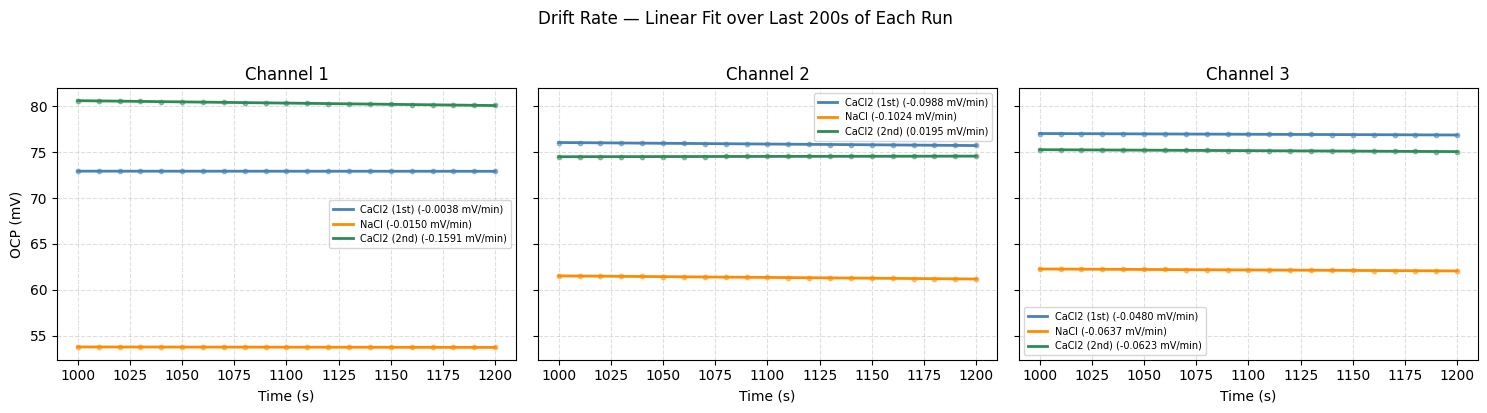

In [38]:
# Plot drift fits for visual confirmation
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

run_colors = {"CaCl2_1": "steelblue", "NaCl": "darkorange", "CaCl2_2": "seagreen"}
run_labels = {"CaCl2_1": "CaCl2 (1st)", "NaCl": "NaCl", "CaCl2_2": "CaCl2 (2nd)"}

for i, ch in enumerate(channels):
    ax = axes[i]
    for run, cols in runs_cols.items():
        col = cols[i]
        
        # Raw data (last 200s)
        ax.scatter(late["t_s"], -late[col] * 1000,
                   color=run_colors[run], s=10, alpha=0.5)
        
        # Linear fit line
        slope, intercept = np.polyfit(late["t_s"], -late[col] * 1000, 1)
        fit_line = slope * late["t_s"] + intercept
        ax.plot(late["t_s"], fit_line,
                color=run_colors[run], linewidth=2,
                label=f"{run_labels[run]} ({slope*60:.4f} mV/min)")

    ax.set_title(f"Channel {ch}")
    ax.set_xlabel("Time (s)")
    if i == 0:
        ax.set_ylabel("OCP (mV)")
    ax.legend(fontsize=7)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Drift Rate — Linear Fit over Last 200s of Each Run", y=1.02)
plt.tight_layout()
plt.savefig("WLT_drift_rate.png", dpi=150, bbox_inches="tight")
plt.show()